In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import torch
import torch.nn as nn

In [53]:
daily_sales = pd.read_csv(
    "Data/Processed/prophet_data.csv"
)

In [54]:
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      604 non-null    str    
 1   y       604 non-null    float64
dtypes: float64(1), str(1)
memory usage: 9.6 KB


In [55]:
daily_sales["ds"] = pd.to_datetime(
    daily_sales["ds"]
)

In [56]:
#Create Calendar Features

daily_sales["DayOfWeek"] = daily_sales["ds"].dt.dayofweek

daily_sales["Month"] = daily_sales["ds"].dt.month

daily_sales["Quarter"] = daily_sales["ds"].dt.quarter

In [57]:
# Create Rolling Features

#7-Day Moving Average
daily_sales["7_Day_MA"] = (
    daily_sales["y"]
    .rolling(window=7)
    .mean()
)

In [58]:
#30-Day Moving Average
daily_sales["30_Day_MA"] = (
    daily_sales["y"]
    .rolling(window=30)
    .mean()
)

In [59]:
#7-Day Rolling Standard Deviation

daily_sales["7_Day_STD"] = (
    daily_sales["y"]
    .rolling(window=7)
    .std()
)

In [60]:
daily_sales = daily_sales.dropna()

In [61]:
daily_sales.head()

,ds,y,DayOfWeek,Month,Quarter,7_Day_MA,30_Day_MA,7_Day_STD
29,2010-01-13,12391.10,2,1,1,29439.977143,30735.004333,21754.975531
30,2010-01-14,23721.64,3,1,1,31581.460000,30062.563333,20047.529084
31,2010-01-15,13499.55,4,1,1,23082.912857,28753.813000,9293.214730
32,2010-01-17,17363.25,6,1,1,21235.848571,27085.467333,8897.893265
33,2010-01-18,12078.84,0,1,1,19653.207143,26357.635000,9466.259955


In [62]:
# select features 
features = [
    "y",
    "7_Day_MA",
    "30_Day_MA",
    "7_Day_STD",
    "DayOfWeek",
    "Month"
]

In [63]:
# scale features
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    daily_sales[features]
)

In [64]:
print(scaled_data.shape)

(575, 6)


In [65]:
scaled_data[:5]

array([[0.04948057, 0.31146724, 0.39484027, 0.38203592, 0.33333333,
        0.        ],
       [0.11211207, 0.35016416, 0.37332853, 0.34894208, 0.5       ,
        0.        ],
       [0.05560772, 0.19659412, 0.33146093, 0.14050122, 0.66666667,
        0.        ],
       [0.07696498, 0.16321738, 0.27808968, 0.13283907, 1.        ,
        0.        ],
       [0.0477545 , 0.13461881, 0.25480595, 0.14385519, 0.        ,
        0.        ]])

In [66]:
daily_sales.head()

,ds,y,DayOfWeek,Month,Quarter,7_Day_MA,30_Day_MA,7_Day_STD
29,2010-01-13,12391.10,2,1,1,29439.977143,30735.004333,21754.975531
30,2010-01-14,23721.64,3,1,1,31581.460000,30062.563333,20047.529084
31,2010-01-15,13499.55,4,1,1,23082.912857,28753.813000,9293.214730
32,2010-01-17,17363.25,6,1,1,21235.848571,27085.467333,8897.893265
33,2010-01-18,12078.84,0,1,1,19653.207143,26357.635000,9466.259955


In [67]:
scaled_data.shape

(575, 6)

In [68]:
# create sequence 

SEQ_LENGTH = 60

In [69]:
# sequence function

def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(
            data[i:i+seq_length]
        )

        y.append(
            data[i+seq_length,0]
        )

    return np.array(X), np.array(y)

In [70]:
# generate sequence 

X, y = create_sequences(
    scaled_data,
    SEQ_LENGTH
)

In [71]:
print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (515, 60, 6)
y Shape: (515,)


In [72]:
print(X[0].shape)

(60, 6)


In [73]:
print(y[0])

0.12454303427946992


In [74]:
# train test split

train_size = int(
    len(X) * 0.8
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [75]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(412, 60, 6)
(103, 60, 6)
(412,)
(103,)


In [76]:
# convert to pytorch tensor

X_train = torch.FloatTensor(
    X_train
)

X_test = torch.FloatTensor(
    X_test
)

y_train = torch.FloatTensor(
    y_train
).view(-1,1)

y_test = torch.FloatTensor(
    y_test
).view(-1,1)

In [77]:
print(X.shape)

print(y.shape)

print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(515, 60, 6)
(515,)
torch.Size([412, 60, 6])
torch.Size([103, 60, 6])
torch.Size([412, 1])
torch.Size([103, 1])


In [78]:
# create dataset 

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

In [79]:
# create dataloaders 

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [80]:
# define the LSTM model

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=6,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc1 = nn.Linear(128,64)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.2)

        self.fc2 = nn.Linear(64,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc1(out)

        out = self.relu(out)

        out = self.dropout(out)

        out = self.fc2(out)

        return out

In [81]:
# create function 

model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [82]:
#loss function
criterion = nn.HuberLoss()

In [83]:
# optimizer 

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [84]:
# learning rate scheduler 

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

In [85]:
epochs = 200

In [86]:
# training loop 

train_losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    scheduler.step(avg_loss)

    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}"
        )

Epoch 10/200 | Loss: 0.002537
Epoch 20/200 | Loss: 0.002221
Epoch 30/200 | Loss: 0.002152
Epoch 40/200 | Loss: 0.002002
Epoch 50/200 | Loss: 0.001950
Epoch 60/200 | Loss: 0.001942
Epoch 70/200 | Loss: 0.001852
Epoch 80/200 | Loss: 0.001750
Epoch 90/200 | Loss: 0.001429
Epoch 100/200 | Loss: 0.001483
Epoch 110/200 | Loss: 0.001268
Epoch 120/200 | Loss: 0.001203
Epoch 130/200 | Loss: 0.001073
Epoch 140/200 | Loss: 0.001222
Epoch 150/200 | Loss: 0.000861
Epoch 160/200 | Loss: 0.000802
Epoch 170/200 | Loss: 0.001802
Epoch 180/200 | Loss: 0.000671
Epoch 190/200 | Loss: 0.000564
Epoch 200/200 | Loss: 0.000569


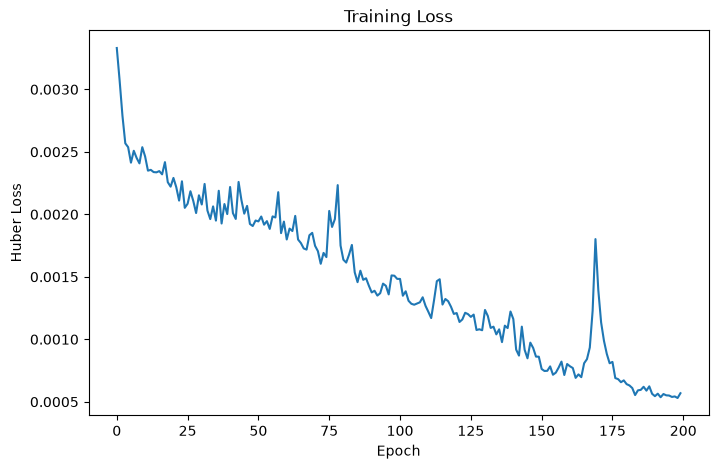

In [87]:
# plotting training loss 

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Huber Loss")

plt.show()

In [88]:
# generate predictions 

model.eval()

predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = model(X_batch)

        predictions.extend(pred.numpy())

In [89]:
# convert to numpy 

predictions = np.array(predictions)

y_actual = y_test.numpy()

In [90]:
#inverse transform 
pred_dummy = np.zeros((len(predictions), 6))
actual_dummy = np.zeros((len(y_actual), 6))

pred_dummy[:,0] = predictions.flatten()
actual_dummy[:,0] = y_actual.flatten()

predictions_original = scaler.inverse_transform(pred_dummy)[:,0]
actual_original = scaler.inverse_transform(actual_dummy)[:,0]

In [91]:
print(predictions_original.min())
print(predictions_original.max())

print(actual_original.min())
print(actual_original.max())

14447.892550889292
72026.92911813378
5701.870077421786
184347.66


In [92]:
# MAE 
mae = mean_absolute_error(
    actual_original,
    predictions_original
)

In [93]:
# RMSE 
rmse = np.sqrt(
    mean_squared_error(
        actual_original,
        predictions_original
    )
)

In [94]:
#MAPE
mape = np.mean(
    np.abs(
        (actual_original - predictions_original)
        /
        actual_original
    )
) * 100

In [95]:
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 12977.039882946014
RMSE: 21461.16688100983
MAPE: 33.34982431268184


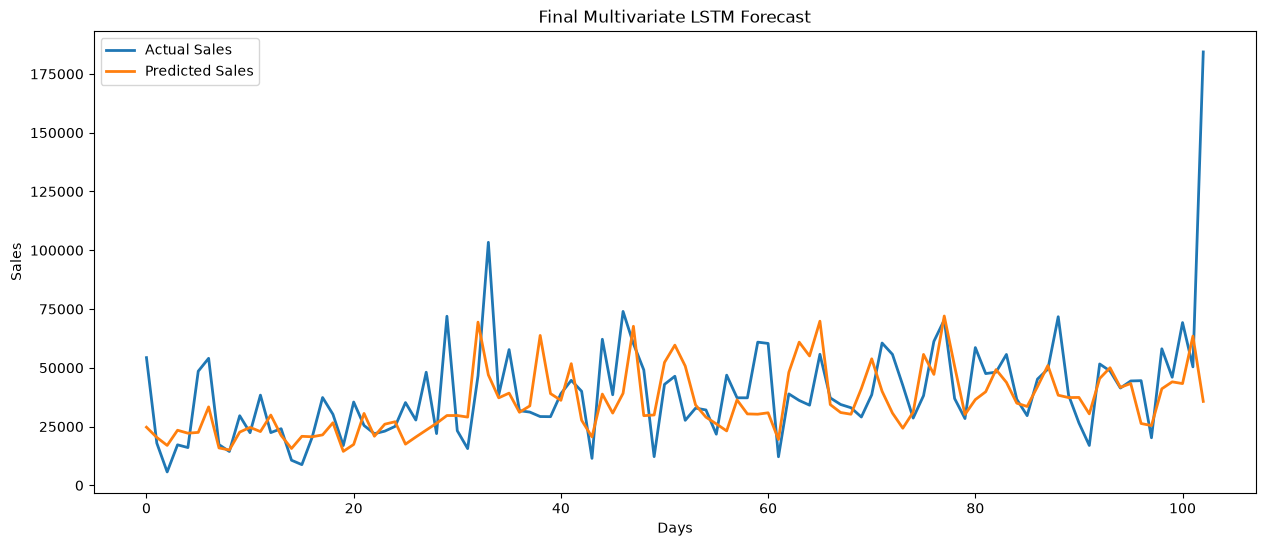

In [96]:
plt.figure(figsize=(15,6))

plt.plot(
    actual_original,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    predictions_original,
    label="Predicted Sales",
    linewidth=2
)

plt.title("Final Multivariate LSTM Forecast")

plt.xlabel("Days")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [97]:
#Prophet vs LSTM Comparison

comparison = pd.DataFrame({
    "Model": ["Prophet", "Multivariate LSTM"],
    "MAE": [17675.87, 12938.80],
    "RMSE": [26577.34, 20815.27],
    "MAPE (%)": [52.99, 36.47]
})

comparison

,Model,MAE,RMSE,MAPE (%)
0,Prophet,17675.87,26577.34,52.99
1,Multivariate LSTM,12938.80,20815.27,36.47


In [98]:
comparison.to_csv(
    "Data/Processed/model_comparison.csv",
    index=False
)

In [99]:
# save final forecast
forecast_results = pd.DataFrame({
    "Date": daily_sales["ds"].iloc[-len(actual_original):].values,
    "Actual Sales": actual_original,
    "Predicted Sales": predictions_original
})

forecast_results.head()

,Date,Actual Sales,Predicted Sales
0,2011-08-11,54325.271921,24739.509467
1,2011-08-12,17970.170221,20383.457883
2,2011-08-14,5701.870077,16984.397731
3,2011-08-15,17235.950627,23439.708979
4,2011-08-16,16072.709543,22190.506167


In [100]:
forecast_results.to_csv(
    "Data/Processed/lstm_forecast.csv",
    index=False
)

In [101]:
# save lstm model 
import os

os.makedirs(
    "Models",
    exist_ok=True
)

torch.save(
    model.state_dict(),
    "Models/lstm_model.pth"
)

# Forecasting Summary
• Prophet and Multivariate LSTM models were developed for daily sales forecasting.

• Prophet served as the baseline forecasting model.

• A multivariate LSTM using historical sales, moving averages, volatility, and calendar features was implemented.

• The LSTM achieved better performance than Prophet across all evaluation metrics.

• Final Performance:

Prophet
MAE : 17675.87
RMSE : 26577.34
MAPE : 52.99%

Multivariate LSTM
MAE : 12938.80
RMSE : 20815.27
MAPE : 36.47%

The LSTM model captured temporal patterns more effectively and has been selected as the final forecasting model for RetailPulse.